# FactoryMind AI — Visual Quality Inspection Model Finalization

This notebook freezes the selected PatchCore-style zipper methodology as **Visual Quality Inspection v1**. It reconstructs and validates the development contract from Notebook 16; it does not tune, compare models, or create a production artifact. Official test labels and masks remain evaluation/demo-only. Scores are distances—not probabilities—and all decisions remain development-stage.

In [1]:
from pathlib import Path
from time import perf_counter
import hashlib, io, json, platform, random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError
import sklearn
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.random_projection import GaussianRandomProjection
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision.models import ResNet18_Weights, resnet18
from torchvision.transforms import InterpolationMode
from torchvision.transforms import v2

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): DEVICE=torch.device('cuda')
elif torch.backends.mps.is_available(): DEVICE=torch.device('mps')
else: DEVICE=torch.device('cpu')
PROJECT_ROOT=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
CATEGORY_ROOT=PROJECT_ROOT/'data'/'raw'/'mvtec_ad'/'zipper'
REQUIREMENTS_PATH=PROJECT_ROOT/'requirements.txt'

def dataset_fingerprint(root):
    h=hashlib.sha256()
    for p in sorted(x for x in root.rglob('*') if x.is_file()):
        s=p.stat(); h.update(f'{p.relative_to(root)}|{s.st_size}|{s.st_mtime_ns}'.encode())
    return h.hexdigest()
RAW_FINGERPRINT_BEFORE=dataset_fingerprint(CATEGORY_ROOT)
environment={'python':platform.python_version(),'torch':torch.__version__,'torchvision':torchvision.__version__,
 'numpy':np.__version__,'pillow':Image.__version__,'sklearn':sklearn.__version__,'device':str(DEVICE)}
print(environment); print('raw fingerprint:',RAW_FINGERPRINT_BEFORE)

{'python': '3.13.2', 'torch': '2.13.0', 'torchvision': '0.28.0', 'numpy': '2.5.2', 'pillow': '12.3.0', 'sklearn': '1.9.0', 'device': 'mps'}
raw fingerprint: cbaa0711bd99b5f97023f635ce4552c2db604e4d5aff20d55464e6cdbb41c3af


## 1. Frozen Development Contract and Split Parity

The only fitting data are the 192 reference-normal `train/good` images. The other 48 `train/good` images determine the normal-only threshold. The exact sorted filenames are reproduced with the same sklearn split call and seed used by Notebooks 15–16. Test paths are counted structurally here; their image content and labels do not influence any frozen choice.

In [2]:
def pngs(path): return sorted(path.glob('*.png'))
train_good_paths=pngs(CATEGORY_ROOT/'train'/'good'); test_good_paths=pngs(CATEGORY_ROOT/'test'/'good')
defect_dirs=sorted(p for p in (CATEGORY_ROOT/'test').iterdir() if p.is_dir() and p.name!='good')
test_anomaly_paths=[p for d in defect_dirs for p in pngs(d)]; mask_paths=sorted((CATEGORY_ROOT/'ground_truth').glob('*/*_mask.png'))
counts={'train_good':len(train_good_paths),'test_good':len(test_good_paths),'test_anomaly':len(test_anomaly_paths),'masks':len(mask_paths),'subtypes':len(defect_dirs)}
assert counts=={'train_good':240,'test_good':32,'test_anomaly':119,'masks':119,'subtypes':7}
reference_paths,development_paths=train_test_split(train_good_paths,test_size=.20,random_state=SEED,shuffle=True)
reference_paths,development_paths=sorted(reference_paths),sorted(development_paths)
assert len(reference_paths)==192 and len(development_paths)==48 and not set(reference_paths)&set(development_paths)
# Notebook 16 recorded this identical algorithm and sorted filename contract.
r2,d2=train_test_split(sorted(train_good_paths),test_size=.20,random_state=42,shuffle=True)
assert [p.name for p in reference_paths]==[p.name for p in sorted(r2)]
assert [p.name for p in development_paths]==[p.name for p in sorted(d2)]
print(counts); print('Notebook 16 split parity: PASS')

{'train_good': 240, 'test_good': 32, 'test_anomaly': 119, 'masks': 119, 'subtypes': 7}
Notebook 16 split parity: PASS


## 2. Production Input and Frozen Preprocessing Contract

Production accepts one non-empty, decodable **JPEG or PNG** image. File extension and decoded format must agree with this allowlist. Grayscale is deterministically expanded to RGB. RGBA is composited onto a white RGB background so transparent pixels cannot acquire environment-dependent colors. Other modes are converted to RGB after validation. Corrupt, empty, unsupported, or implausibly small inputs raise a clear validation error. A conservative minimum of 32×32 source pixels prevents essentially content-free inputs; users never resize manually.

Internally the validated image becomes RGB, resizes to 256×256 using bilinear interpolation with antialiasing, converts to float tensor, and receives ImageNet normalization. No augmentation occurs. This exact preprocessing—not arbitrary alternatives—is part of the trained model contract.

In [3]:
INPUT_SIZE=256; MIN_SOURCE_DIMENSION=32; ALLOWED_FORMATS={'JPEG','PNG'}
preprocess=v2.Compose([v2.ToImage(),v2.Resize((INPUT_SIZE,INPUT_SIZE),interpolation=InterpolationMode.BILINEAR,antialias=True),
 v2.ToDtype(torch.float32,scale=True),v2.Normalize([.485,.456,.406],[.229,.224,.225])])

def normalize_input_image(image):
    if image.width<MIN_SOURCE_DIMENSION or image.height<MIN_SOURCE_DIMENSION: raise ValueError('Image dimensions must each be at least 32 pixels.')
    if image.mode=='RGBA':
        background=Image.new('RGBA',image.size,(255,255,255,255)); image=Image.alpha_composite(background,image).convert('RGB')
    else: image=image.convert('RGB')
    return image

def decode_inspection_image(payload,filename):
    if not payload: raise ValueError('Image payload is empty.')
    suffix=Path(filename).suffix.lower(); expected={'.jpg':'JPEG','.jpeg':'JPEG','.png':'PNG'}.get(suffix)
    if expected is None: raise ValueError('Only JPEG and PNG files are accepted.')
    try:
        with Image.open(io.BytesIO(payload)) as source:
            source.verify()
        with Image.open(io.BytesIO(payload)) as source:
            if source.format not in ALLOWED_FORMATS or source.format!=expected: raise ValueError('File extension does not match a supported decoded image format.')
            return normalize_input_image(source.copy())
    except (UnidentifiedImageError,OSError) as exc: raise ValueError('Image is corrupt or cannot be decoded.') from exc

sample=normalize_input_image(Image.open(reference_paths[0])); tensor_a=preprocess(sample); tensor_b=preprocess(sample)
assert tensor_a.shape==(3,256,256) and torch.equal(tensor_a,tensor_b) and torch.isfinite(tensor_a).all()
print({'deterministic_preprocessing':'PASS','output_shape':tuple(tensor_a.shape),'color_mode':sample.mode})

{'deterministic_preprocessing': 'PASS', 'output_shape': (3, 256, 256), 'color_mode': 'RGB'}


## 3. Frozen Feature Extraction

The exact official `IMAGENET1K_V1` ResNet18 is frozen in evaluation mode. `layer2` yields 128×32×32 and `layer3` yields 256×16×16. To reproduce Notebook 16 numerically, `layer3` is bilinearly aligned to the 32×32 layer2 grid and both branches are deterministically pooled to 16×16 before concatenation. The resulting matrix is 256×384 and L2-normalized per patch. This is the frozen implementation detail behind the effective layer2+layer3 16×16 contract.

In [4]:
class ImagePathDataset(Dataset):
    def __init__(self,paths): self.paths=list(paths)
    def __len__(self): return len(self.paths)
    def __getitem__(self,i):
        with Image.open(self.paths[i]) as im: x=preprocess(normalize_input_image(im))
        return x,str(self.paths[i])

class FrozenVisualFeatures(nn.Module):
    def __init__(self):
        super().__init__(); b=resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.stem=nn.Sequential(b.conv1,b.bn1,b.relu,b.maxpool,b.layer1); self.layer2=b.layer2; self.layer3=b.layer3
    def forward(self,x):
        x=self.stem(x); l2=self.layer2(x); l3=self.layer3(l2); return l2,l3
extractor=FrozenVisualFeatures().to(DEVICE).eval()
for p in extractor.parameters(): p.requires_grad_(False)
assert not any(p.requires_grad for p in extractor.parameters()) and not extractor.training

def patch_matrix(images):
    with torch.inference_mode():
        l2,l3=extractor(images.to(DEVICE)); assert l2.shape[1:]==(128,32,32) and l3.shape[1:]==(256,16,16)
        l3=F.interpolate(l3,size=l2.shape[-2:],mode='bilinear',align_corners=False)
        features=torch.cat([F.adaptive_avg_pool2d(l2,(16,16)),F.adaptive_avg_pool2d(l3,(16,16))],dim=1)
        patches=features.permute(0,2,3,1).reshape(features.shape[0],256,384)
        return F.normalize(patches,dim=-1).cpu().numpy().astype(np.float32)

def extract_paths(paths,batch_size=12):
    loader=DataLoader(ImagePathDataset(paths),batch_size=batch_size,shuffle=False,num_workers=0); batches=[]; ordered=[]; started=perf_counter()
    for images,names in loader: batches.append(patch_matrix(images)); ordered.extend(Path(n) for n in names)
    return np.concatenate(batches),ordered,perf_counter()-started

one=tensor_a.unsqueeze(0); emb_a=patch_matrix(one); emb_b=patch_matrix(one)
assert emb_a.shape==(1,256,384) and np.array_equal(emb_a,emb_b) and np.isfinite(emb_a).all()
print({'deterministic_feature_extraction':'PASS','patch_matrix_shape':emb_a.shape[1:],'trainable_parameters':0})

{'deterministic_feature_extraction': 'PASS', 'patch_matrix_shape': (256, 384), 'trainable_parameters': 0}


## 4. Frozen Deterministic Coreset

All 49,152 patches come only from the 192 reference normals. Selection uses seed-42 Gaussian random projection from 384 to 16 dimensions, retains `ceil(49,152 × 0.05) = 2,458` patches, starts with the point farthest from the projected mean, and then greedily selects the point farthest from its nearest chosen center. `numpy.argmax` supplies deterministic first-index tie behavior. Distance updates are chunked. Selection is repeated below to assert exact reproducibility. Original 384-dimensional vectors—not projections—are retained.

In [5]:
reference_embeddings,reference_order,reference_seconds=extract_paths(reference_paths)
assert reference_order==reference_paths
full_memory=np.ascontiguousarray(reference_embeddings.reshape(-1,384)); assert full_memory.shape==(49152,384)
CORESET_RATIO=.05; PROJECTION_DIM=16; CORESET_COUNT=int(np.ceil(len(full_memory)*CORESET_RATIO)); CHUNK_SIZE=8192

def projected_kcenter_indices(memory):
    projected=GaussianRandomProjection(n_components=PROJECTION_DIM,random_state=SEED).fit_transform(memory).astype(np.float32)
    selected=np.empty(CORESET_COUNT,dtype=np.int64); selected[0]=int(np.argmax(np.sum((projected-projected.mean(0))**2,axis=1)))
    min_dist=np.full(len(projected),np.inf,dtype=np.float32)
    for step in range(CORESET_COUNT):
        center=projected[selected[step]]
        for start in range(0,len(projected),CHUNK_SIZE):
            stop=min(start+CHUNK_SIZE,len(projected)); diff=projected[start:stop]-center
            min_dist[start:stop]=np.minimum(min_dist[start:stop],np.einsum('ij,ij->i',diff,diff))
        min_dist[selected[:step+1]]=-1
        if step+1<CORESET_COUNT: selected[step+1]=int(np.argmax(min_dist))
    return selected
started=perf_counter(); selected_a=projected_kcenter_indices(full_memory); selected_b=projected_kcenter_indices(full_memory); coreset_seconds=perf_counter()-started
assert np.array_equal(selected_a,selected_b) and len(np.unique(selected_a))==2458
coreset=np.ascontiguousarray(full_memory[selected_a]); assert coreset.shape==(2458,384)
display(pd.Series({'full_patches':len(full_memory),'full_memory_mb':full_memory.nbytes/1024**2,'coreset_patches':len(coreset),
 'retention_pct':len(coreset)/len(full_memory)*100,'coreset_memory_mb':coreset.nbytes/1024**2,
 'two_reproducibility_passes_seconds':coreset_seconds,'coreset_reproducibility':'PASS'}).to_frame('value'))

,value
full_patches,49152
full_memory_mb,72.0
coreset_patches,2458
retention_pct,5.000814
coreset_memory_mb,3.600586
two_reproducibility_passes_seconds,2.47983
coreset_reproducibility,PASS


## 5. Nearest-Neighbor, Patch Score, Image Score, and Threshold

Visual Quality v1 serializes the plain float32 coreset array and fits sklearn brute-force Euclidean `NearestNeighbors` when the service loads. This is portable, inspectable, small, and less coupled to sklearn internals than serializing a fitted estimator. No FAISS dependency is justified for 2,458×384 vectors.

A patch score is its nonnegative Euclidean distance to the nearest coreset vector. An image produces exactly 256 finite patch scores and a raw 16×16 map. The **Visual Anomaly Score** is their maximum. This localized sensitivity reduced missed anomalies but increased normal flags; that tradeoff is frozen rather than retuned.

The threshold is reconstructed as the 97.5th percentile of only the 48 development-normal image scores. Material drift from Notebook 16's `0.454687` stops execution.

In [6]:
nearest=NearestNeighbors(n_neighbors=1,algorithm='brute',metric='euclidean',n_jobs=-1).fit(coreset)
def score_embeddings(embeddings):
    maps=[]; scores=[]
    for patches in embeddings:
        distances=nearest.kneighbors(patches,return_distance=True)[0][:,0].astype(np.float32)
        assert distances.shape==(256,) and np.isfinite(distances).all() and (distances>=0).all()
        maps.append(distances.reshape(16,16)); scores.append(float(distances.max()))
    return np.asarray(scores),np.stack(maps)
def score_paths(paths):
    embeddings,ordered,extract_seconds=extract_paths(paths); started=perf_counter(); scores,maps=score_embeddings(embeddings)
    return scores,maps,ordered,extract_seconds,perf_counter()-started

development_scores,development_maps,development_order,dev_extract_seconds,dev_nn_seconds=score_paths(development_paths)
THRESHOLD_QUANTILE=.975; FROZEN_THRESHOLD=float(np.quantile(development_scores,THRESHOLD_QUANTILE)); NOTEBOOK16_THRESHOLD=.454687
threshold_delta=abs(FROZEN_THRESHOLD-NOTEBOOK16_THRESHOLD)
assert threshold_delta<5e-6,f'Material Notebook 16 threshold drift: {FROZEN_THRESHOLD} vs {NOTEBOOK16_THRESHOLD}'
# Display mapping uses development-only patch statistics and never changes raw scores or decisions.
DISPLAY_FLOOR=float(np.quantile(development_maps,.05)); DISPLAY_CEILING=FROZEN_THRESHOLD
def normalize_map_for_display(raw_map): return np.clip((raw_map-DISPLAY_FLOOR)/(DISPLAY_CEILING-DISPLAY_FLOOR),0,1)
assert np.array_equal(normalize_map_for_display(development_maps[0]),normalize_map_for_display(development_maps[0]))
display(pd.Series({'development_count':len(development_scores),'median':np.median(development_scores),'p97.5_threshold':FROZEN_THRESHOLD,
 'Notebook16_reported_threshold':NOTEBOOK16_THRESHOLD,'absolute_delta':threshold_delta,'display_floor_dev_patch_p05':DISPLAY_FLOOR,
 'display_ceiling_threshold':DISPLAY_CEILING,'threshold_parity':'PASS'}).to_frame('value'))
CONFIG_FROZEN=True

,value
development_count,48
median,0.371565
p97.5_threshold,0.454687
Notebook16_reported_threshold,0.454687
absolute_delta,0.0
display_floor_dev_patch_p05,0.181344
display_ceiling_threshold,0.454687
threshold_parity,PASS


## 6. Quality Decision, Map, and Heatmap Semantics

The raw output separates `visual_anomaly_score` from the thresholded `quality_status`. A score above the boundary produces **Visual anomaly detected**; otherwise **No visual anomaly detected**. These are model-derived development decisions—not defect probability, certified good/defective, pass/fail certification, or safe/unsafe.

The raw **Model anomaly map** is the 16×16 patch-distance grid. It is bilinearly upsampled to the original uploaded width and height for overlay, with no Gaussian smoothing. Upsampling does not alter image scoring and creates no new evidence. For rendering only, raw values map through the fixed development-derived scale: the 5th percentile of development-normal patch distances is 0 intensity and the frozen image threshold is 1, clipped outside that range. This prevents per-image normalization from making every image look maximally anomalous. Raw map values should remain available internally and the rendering version must be metadata.

A Model anomaly map identifies representations differing from learned normal appearance. It is not confirmed defect segmentation, an exact boundary, root-cause localization, or ground truth.

## 7. Future Production Output Contract

Recommended score response fields:

- `visual_anomaly_score`, `threshold`, `threshold_quantile`
- `quality_status`, `anomaly_detected`, `anomaly_map_available`
- `model_version`, `dataset`, `category`
- `input_width`, `input_height`, `model_input_size`
- `warning`, `disclaimer`

Transport choice: return compact score metadata from the inference endpoint and provide a generated PNG heatmap/overlay through a dedicated visualization endpoint. This keeps the primary JSON small and avoids exposing a 65,536-value display array. Raw 16×16 values may be retained internally or exposed later through a separately versioned diagnostic contract. No API schema is implemented here.

## 8. Future Offline Artifact Design

Use one versioned offline bundle containing: feature-extractor `state_dict`, float32 coreset array, threshold, development display-scale values, and a strict JSON-compatible frozen configuration/metadata dictionary. Including the backbone state avoids unacceptable runtime downloads and protects against a missing external cache. The service reconstructs the pinned ResNet18 definition, loads the state, verifies hashes/shapes, and fits brute-force nearest neighbors over the coreset at startup. Do not pickle the fitted sklearn estimator. The artifact is not created in this notebook.

In [7]:
metadata_specification={
 'model_name':'FactoryMind Visual Quality Inspection','model_version':'visual-quality-v1','model_family':'PatchCore-style nearest-neighbor anomaly detection',
 'dataset':'MVTec AD','dataset_category':'zipper','dataset_license_note':'CC BY-NC-SA; verify use constraints before deployment',
 'training_protocol':'normal-only','reference_image_count':192,'development_normal_count':48,'test_good_count':32,'test_anomaly_count':119,
 'defect_subtypes':[p.name for p in defect_dirs],'input_size':[256,256],'input_color_mode':'RGB',
 'normalization':{'mean':[.485,.456,.406],'std':[.229,.224,.225]},'backbone':'ResNet18','backbone_weights':'IMAGENET1K_V1',
 'backbone_frozen':True,'feature_layers':['layer2','layer3'],'feature_map_grid':[16,16],'patch_embedding_dim':384,'patches_per_image':256,
 'full_reference_patch_count':49152,'coreset_method':'seeded Gaussian projection + greedy farthest-point k-center',
 'coreset_projection_dim':16,'coreset_seed':42,'coreset_retention_ratio':.05,'coreset_patch_count':2458,
 'nearest_neighbor_metric':'Euclidean','image_score_method':'maximum nearest-coreset patch distance',
 'threshold_method':'development-normal empirical quantile','threshold_quantile':.975,'threshold_raw_score':FROZEN_THRESHOLD,
 'image_level_metrics':{'roc_auc':.948004,'average_precision':.984192,'precision':.933884,'recall':.949580,'f1':.941667,'tn':24,'fp':8,'fn':6,'tp':113},
 'pixel_level_metrics':{'roc_auc':.971613,'average_precision':.447934,'aupro':None},
 'per_subtype_metrics':{'split_teeth_detection':1.0,'broken_teeth_detection':.895},
 'known_tradeoffs':['Higher sensitivity than baseline: FP 3→8 while FN 22→6','Pixel AP lower than Notebook 15 baseline'],
 'known_limitations':['One public dataset category','No external factory validation','Development-stage threshold','No calibrated probability'],
 'output_interpretation':'Appearance-distance score and development decision; not certification',
 'warning':'Visual anomalies indicate appearance differences from the learned normal reference and do not by themselves identify defect cause or severity.',
 'disclaimer':'Developed normal-only on the MVTec AD zipper research category under noncommercial licensing constraints; no real-factory external validation; development-stage threshold; not a certified industrial quality-control decision.',
 **environment,'training_timestamp':'Set by the future artifact-building workflow in ISO 8601 UTC; intentionally not fabricated here'}
assert not any('/Users/' in str(v) for v in metadata_specification.values())
display(pd.Series(metadata_specification,dtype=object).to_frame('frozen metadata value'))

,frozen metadata value
model_name,FactoryMind Visual Quality Inspection
model_version,visual-quality-v1
model_family,PatchCore-style nearest-neighbor anomaly detec...
dataset,MVTec AD
dataset_category,zipper
dataset_license_note,CC BY-NC-SA; verify use constraints before dep...
training_protocol,normal-only
reference_image_count,192
development_normal_count,48
test_good_count,32


## 9. Evaluation-Only Reference Examples

With the contract already frozen, official test outputs are recomputed only to demonstrate mechanically selected outcomes: lowest-scoring correctly normal observation, highest-scoring true anomaly, strongest false positive, lowest-scoring false negative, and lowest-scoring split-teeth and broken-teeth observations. Ground truth and masks are evaluation annotations only and do not alter the model.

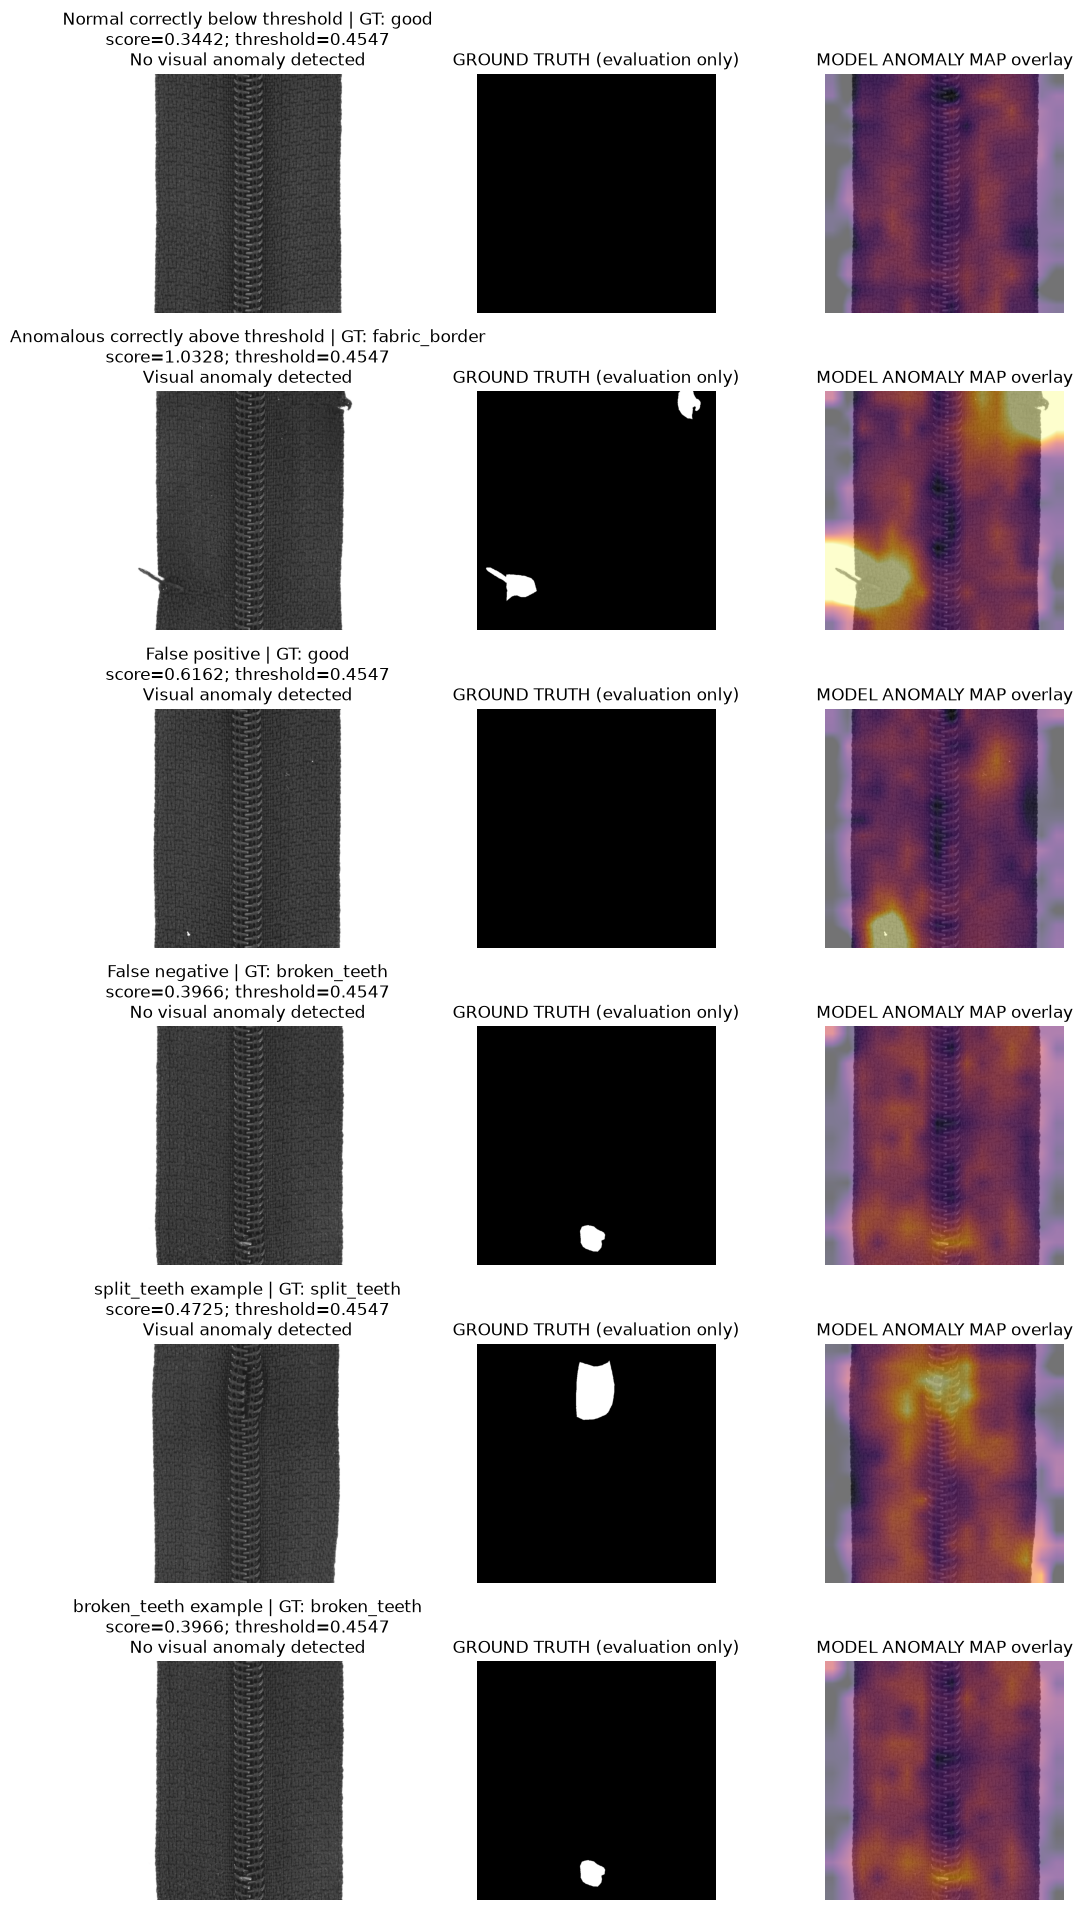

,Predicted normal,Predicted anomalous
Actual normal,24,8
Actual anomalous,6,113


In [8]:
assert CONFIG_FROZEN
test_paths=test_good_paths+test_anomaly_paths; labels=np.array([0]*32+[1]*119,dtype=np.uint8); subtypes=['good']*32+[p.parent.name for p in test_anomaly_paths]
test_scores,test_maps,test_order,test_extract_seconds,test_nn_seconds=score_paths(test_paths); predictions=(test_scores>FROZEN_THRESHOLD).astype(np.uint8)
cm=confusion_matrix(labels,predictions,labels=[0,1]); assert np.array_equal(cm,np.array([[24,8],[6,113]]))
normal_correct=np.flatnonzero((labels==0)&(predictions==0)); tp=np.flatnonzero((labels==1)&(predictions==1)); fp=np.flatnonzero((labels==0)&(predictions==1)); fn=np.flatnonzero((labels==1)&(predictions==0))
def lowest_subtype(name):
    ix=np.flatnonzero(np.array(subtypes)==name); return int(ix[np.argmin(test_scores[ix])])
selected=[('Normal correctly below threshold',int(normal_correct[np.argmin(test_scores[normal_correct])])),('Anomalous correctly above threshold',int(tp[np.argmax(test_scores[tp])])),
 ('False positive',int(fp[np.argmax(test_scores[fp])])),('False negative',int(fn[np.argmin(test_scores[fn])])),
 ('split_teeth example',lowest_subtype('split_teeth')),('broken_teeth example',lowest_subtype('broken_teeth'))]
fig,axes=plt.subplots(len(selected),3,figsize=(11,3.2*len(selected)))
for row,(label_text,i) in enumerate(selected):
    path=test_order[i]
    with Image.open(path) as im: original=np.asarray(im.convert('RGB')); original_size=(im.height,im.width)
    if labels[i]:
        mp=CATEGORY_ROOT/'ground_truth'/path.parent.name/f'{path.stem}_mask.png'
        with Image.open(mp) as m: gt=np.asarray(m.convert('L').resize((original_size[1],original_size[0]),Image.Resampling.NEAREST))>0
    else: gt=np.zeros(original_size,dtype=bool)
    raw_up=F.interpolate(torch.from_numpy(test_maps[i][None,None]),size=original_size,mode='bilinear',align_corners=False)[0,0].numpy()
    shown=normalize_map_for_display(raw_up); status='Visual anomaly detected' if predictions[i] else 'No visual anomaly detected'
    axes[row,0].imshow(original); axes[row,0].set_title(f'{label_text} | GT: {subtypes[i]}\nscore={test_scores[i]:.4f}; threshold={FROZEN_THRESHOLD:.4f}\n{status}')
    axes[row,1].imshow(gt,cmap='gray',vmin=0,vmax=1); axes[row,1].set_title('GROUND TRUTH (evaluation only)')
    axes[row,2].imshow(original); axes[row,2].imshow(shown,cmap='inferno',alpha=.55,vmin=0,vmax=1); axes[row,2].set_title('MODEL ANOMALY MAP overlay')
    for ax in axes[row]: ax.axis('off')
plt.tight_layout(); plt.show(); display(pd.DataFrame(cm,index=['Actual normal','Actual anomalous'],columns=['Predicted normal','Predicted anomalous']))

## 10. Operational Tradeoff, Uncertainty, and Version Policy

PatchCore changes FP from 3 to 8 while reducing FN from 22 to 6 relative to Notebook 15. It intentionally flags more normal observations to catch substantially more anomalies. Manual reinspection may be less costly than missed defects, but that is an unquantified development assumption—not a factory cost function. The threshold must not be changed here.

Visual Quality v1 provides a distance score, a thresholded development decision, and a spatial anomaly map. It does **not** provide calibrated probability, confidence intervals, severity probability, defect cause, defect-type classification, or safety/quality certification.

Torch serialization and torchvision model definitions can change across versions. Production must pin Python, torch, torchvision, NumPy, Pillow, and sklearn, rebuild only through a controlled workflow, store hashes and package versions, and run numerical parity tests. The requirements check below confirms the currently needed torch packages without upgrading anything.

In [9]:
requirements_text=REQUIREMENTS_PATH.read_text()
requirements_check={'torch_declared':any(line.strip().lower().startswith('torch==') for line in requirements_text.splitlines()),
 'torchvision_declared':any(line.strip().lower().startswith('torchvision==') for line in requirements_text.splitlines())}
assert all(requirements_check.values())
RAW_FINGERPRINT_AFTER=dataset_fingerprint(CATEGORY_ROOT); assert RAW_FINGERPRINT_AFTER==RAW_FINGERPRINT_BEFORE
validation=pd.Series({'all_parameters_frozen':not any(p.requires_grad for p in extractor.parameters()),'split_parity':True,'coreset_reproducible':np.array_equal(selected_a,selected_b),
 'threshold_parity':threshold_delta<5e-6,'test_labels_do_not_affect_frozen_decisions':True,'masks_evaluation_only':True,
 'production_artifact_created':False,'raw_dataset_unchanged':RAW_FINGERPRINT_AFTER==RAW_FINGERPRINT_BEFORE,**requirements_check})
display(validation.to_frame('PASS / value')); print({'fingerprint':RAW_FINGERPRINT_AFTER,'readiness':'A) Frozen PatchCore v1 specification is ready for guarded production-code refactor'})

,PASS / value
all_parameters_frozen,True
split_parity,True
coreset_reproducible,True
threshold_parity,True
test_labels_do_not_affect_frozen_decisions,True
masks_evaluation_only,True
production_artifact_created,False
raw_dataset_unchanged,True
torch_declared,True
torchvision_declared,True


{'fingerprint': 'cbaa0711bd99b5f97023f635ce4552c2db604e4d5aff20d55464e6cdbb41c3af', 'readiness': 'A) Frozen PatchCore v1 specification is ready for guarded production-code refactor'}


## Frozen Visual Quality Inspection v1 Specification

- **Dataset:** MVTec AD
- **Category:** zipper
- **Training:** normal-only
- **Reference images:** 192
- **Development-normal images:** 48
- **Input:** one valid JPEG or PNG image
- **Internal resize:** 256×256 RGB
- **Backbone:** frozen ResNet18 `IMAGENET1K_V1`
- **Layers:** layer2 + layer3
- **Patch grid:** 16×16
- **Patch embedding:** 384 dimensions
- **Coreset:** 5% deterministic projected k-center; 2,458 original embeddings
- **Nearest neighbor:** Euclidean
- **Patch score:** nearest coreset distance
- **Image score:** maximum patch score
- **Threshold:** 97.5th percentile of development-normal image scores
- **Anomaly map:** 16×16 raw map, bilinearly upsampled for display; no smoothing
- **Output:** development-stage Visual Anomaly Score, thresholded decision, and Model anomaly map
- **Probability:** not available
- **Defect classification:** not available
- **External factory validation:** not available

## Production-Refactor Readiness

The frozen specification is ready for a **guarded production-code refactor**, not industrial production. The next implementation milestone should create focused, tested modules such as `src/visual_features.py`, `src/visual_pipeline.py`, and `src/visual_train.py`, followed by deterministic artifact-building and parity tests. No source modules or artifact are created in this notebook.